<a href="https://www.kaggle.com/code/sonawanelalitsunil/top-100-hits-of-2025-ml-0-75?scriptVersionId=265003310" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-100-hits-songs-of-2025/youtube-top-100-songs-2025.csv


## 🎶 Top 100 Hits of 2025: A Year in Music

## Description:
The year 2025 has been packed with unforgettable music, showcasing the best hits across pop, hip-hop, R&B, indie, rock, and Latin genres. From chart-topping collaborations like Kendrick Lamar & SZA’s Luther and Lady Gaga & Bruno Mars’ Die With a Smile, to breakout hits from emerging artists such as Huntr/x, Sabrina Carpenter, and Doechii, the year’s music scene has been vibrant and diverse. Genre-crossing tracks, streaming milestones, and global influences highlight how artists continue to push creative boundaries, blending sounds and styles that captivate audiences worldwide. Whether you love high-energy pop anthems, soulful R&B, indie breakthroughs, or Latin rhythms, the Top 100 Hits of 2025 offer something for every music fan, defining the soundtrack of the year.

## Import dataset

In [2]:
df= pd.read_csv("/kaggle/input/top-100-hits-songs-of-2025/youtube-top-100-songs-2025.csv")

In [3]:
df.head()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
0,ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT. (Official Music Video),ROSÉ & Bruno Mars - APT.\nDownload/stream: ht...,2009014557,Music,YG Entertainment;YG;와이지;K-pop;BLACKPINK;블랙핑크;블...,173,2:53,False,https://i.ytimg.com/vi_webp/ekr2nIex040/maxres...,ROSÉ,https://www.youtube.com/channel/UCBo1hnzxV9rz3...,19200000
1,"Lady Gaga, Bruno Mars - Die With A Smile (Offi...","Lady Gaga, Bruno Mars - Die With A Smile (Offi...",MAYHEM OUT NOW\nhttp://ladygaga.com \n \nListe...,1324833300,Music,Lady Gaga;Bruno Mars;Interscope;Pop,252,4:12,False,https://i.ytimg.com/vi/kPa7bsKwL-c/maxresdefau...,Lady Gaga,https://www.youtube.com/channel/UC07Kxew-cMIay...,29600000
2,Reneé Rapp - Leave Me Alone (Official Music Vi...,Reneé Rapp - Leave Me Alone (Official Music Vi...,"Listen to “BITE ME”, the new album from Reneé ...",2536628,Music,Reneé Rapp;Interscope Records;Pop,160,2:40,False,https://i.ytimg.com/vi/tiPWzFLiz4A/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000
3,Billie Eilish - BIRDS OF A FEATHER (Official M...,Billie Eilish - BIRDS OF A FEATHER (Official M...,Listen to HIT ME HARD AND SOFT: https://billie...,558329099,Music,Billie Eilish;Darkroom/Interscope Records;Alte...,231,3:51,False,https://i.ytimg.com/vi/V9PVRfjEBTI/maxresdefau...,Billie Eilish,https://www.youtube.com/channel/UCDGmojLIoWpXo...,56800000
4,Reneé Rapp - Mad (Official Music Video),Reneé Rapp - Mad (Official Music Video),"Listen to “BITE ME”, the new album from Reneé ...",2113548,Music,Reneé Rapp;Interscope Records;Pop,180,3:00,False,https://i.ytimg.com/vi/xkWQM3flsiY/maxresdefau...,Reneé Rapp,https://www.youtube.com/channel/UCZy4ki_L4bzw9...,408000


In [4]:
df.tail()

,title,fulltitle,description,view_count,categories,tags,duration,duration_string,live_status,thumbnail,channel,channel_url,channel_follower_count
95,Ariana Grande - twilight zone (Official Lyric ...,Ariana Grande - twilight zone (Official Lyric ...,The official “twilight zone” official lyric vi...,18245315,Music,Ariana Grande;Republic Records;Pop,202,3:22,False,https://i.ytimg.com/vi/x1XIJM6spaE/maxresdefau...,Ariana Grande,https://www.youtube.com/channel/UC0VOyT2OCBKdQ...,56400000
96,"Gracie Abrams - I Love You, I’m Sorry (Officia...","Gracie Abrams - I Love You, I’m Sorry (Officia...","Listen to the new album, The Secret of Us, out...",31456772,Music,"Gracie Abrams;Gracie Abrams, under exclusive l...",234,3:54,False,https://i.ytimg.com/vi/uxjhN_Donfw/maxresdefau...,Gracie Abrams,https://www.youtube.com/channel/UCVFRVXH1hRoWk...,1770000
97,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino ft. FCG Heem - Miami (Official...,HoodTrophy Bino and FCG Heem drop Miami. From...,66051,Music,NaN,197,3:17,False,https://i.ytimg.com/vi_webp/I-gmbHgeN1I/maxres...,HoodTrophy Bino,https://www.youtube.com/channel/UCsaZi3QZrZ5-s...,20300
98,Sean Paul x INNA - Let It Talk To Me,Sean Paul x INNA - Let It Talk To Me,Song Title: Sean Paul x INNA - Let It Talk To ...,16952860,Music,Sean Paul,155,2:35,False,https://i.ytimg.com/vi_webp/nkRyAVQdqAA/maxres...,Sean Paul,https://www.youtube.com/channel/UCkdc7gHpavxpg...,5200000
99,"Selena Gomez, benny blanco - How Does It Feel ...","Selena Gomez, benny blanco - How Does It Feel ...",Listen to the new album 'I Said I Love You Fir...,16971256,Music,Selena Gomez;benny blanco;SMG Music LLC Friend...,161,2:41,False,https://i.ytimg.com/vi/4LcNr0T2yAA/maxresdefau...,Selena Gomez,https://www.youtube.com/channel/UCjK8ORC71kwyj...,35500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   title                   100 non-null    object
 1   fulltitle               100 non-null    object
 2   description             100 non-null    object
 3   view_count              100 non-null    int64 
 4   categories              100 non-null    object
 5   tags                    85 non-null     object
 6   duration                100 non-null    int64 
 7   duration_string         100 non-null    object
 8   live_status             100 non-null    bool  
 9   thumbnail               100 non-null    object
 10  channel                 100 non-null    object
 11  channel_url             100 non-null    object
 12  channel_follower_count  100 non-null    int64 
dtypes: bool(1), int64(3), object(9)
memory usage: 9.6+ KB


In [6]:
df.describe()

,view_count,duration,channel_follower_count
count,1.000000e+02,100.000000,1.000000e+02
mean,1.059103e+08,203.900000,1.612067e+07
std,2.491132e+08,44.260592,1.980038e+07
min,1.161000e+03,120.000000,1.000000e+00
25%,1.852702e+07,173.000000,6.132500e+05
50%,3.798224e+07,193.500000,6.320000e+06
75%,1.111073e+08,231.750000,2.760000e+07
max,2.009015e+09,354.000000,7.620000e+07


In [7]:
df.isnull().sum()

title                      0
fulltitle                  0
description                0
view_count                 0
categories                 0
tags                      15
duration                   0
duration_string            0
live_status                0
thumbnail                  0
channel                    0
channel_url                0
channel_follower_count     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

title                     100
fulltitle                 100
description               100
view_count                100
categories                  2
tags                       76
duration                   69
duration_string            69
live_status                 1
thumbnail                 100
channel                    65
channel_url                69
channel_follower_count     65
dtype: int64

In [10]:
df.shape

(100, 13)

In [11]:
df.dtypes

title                     object
fulltitle                 object
description               object
view_count                 int64
categories                object
tags                      object
duration                   int64
duration_string           object
live_status                 bool
thumbnail                 object
channel                   object
channel_url               object
channel_follower_count     int64
dtype: object

In [12]:
df.describe().loc[['mean','min','max']].T

,mean,min,max
view_count,1.059103e+08,1161.0,2.009015e+09
duration,2.039000e+02,120.0,3.540000e+02
channel_follower_count,1.612067e+07,1.0,7.620000e+07


In [13]:
df.columns

Index(['title', 'fulltitle', 'description', 'view_count', 'categories', 'tags',
       'duration', 'duration_string', 'live_status', 'thumbnail', 'channel',
       'channel_url', 'channel_follower_count'],
      dtype='object')

## Data visualizations

In [14]:
df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce')
df['channel_follower_count'] = pd.to_numeric(df['channel_follower_count'], errors='coerce')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

# Fill missing values
df['categories'] = df['categories'].fillna('Unknown')
df['tags'] = df['tags'].fillna('No Tags')

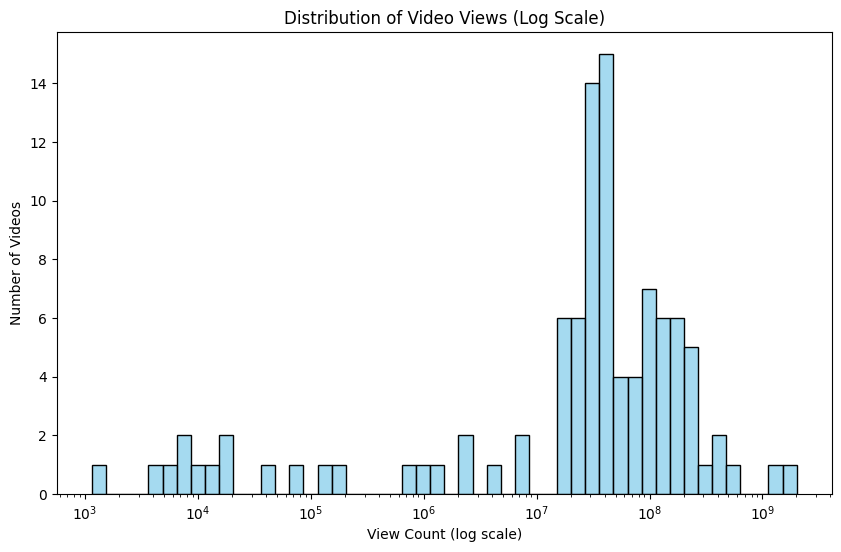

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['view_count'], bins=50, log_scale=True, color='skyblue')
plt.title("Distribution of Video Views (Log Scale)")
plt.xlabel("View Count (log scale)")
plt.ylabel("Number of Videos")
plt.show()

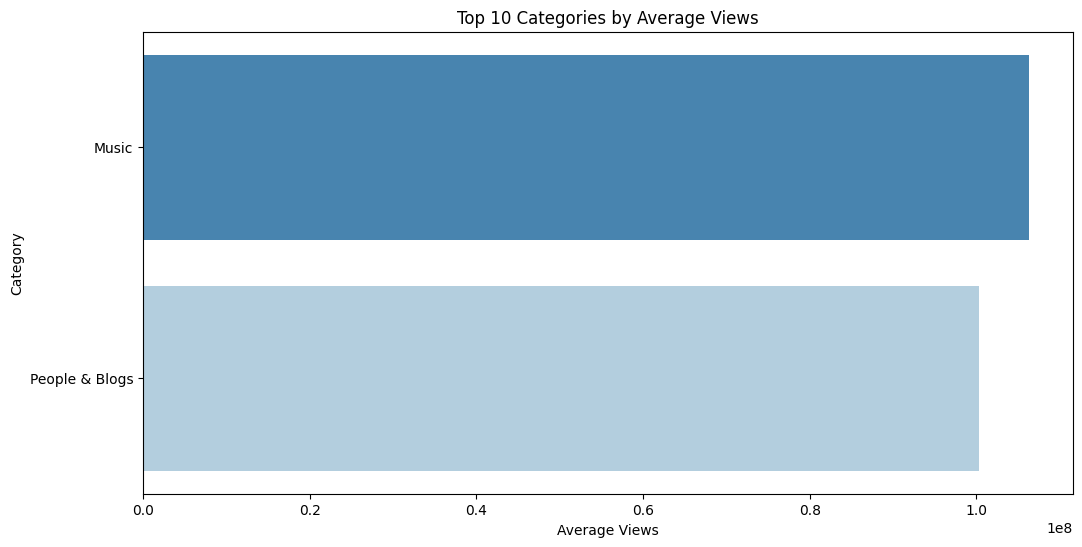

In [16]:
top_categories = df.groupby('categories')['view_count'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='Blues_r')
plt.title("Top 10 Categories by Average Views")
plt.xlabel("Average Views")
plt.ylabel("Category")
plt.show()

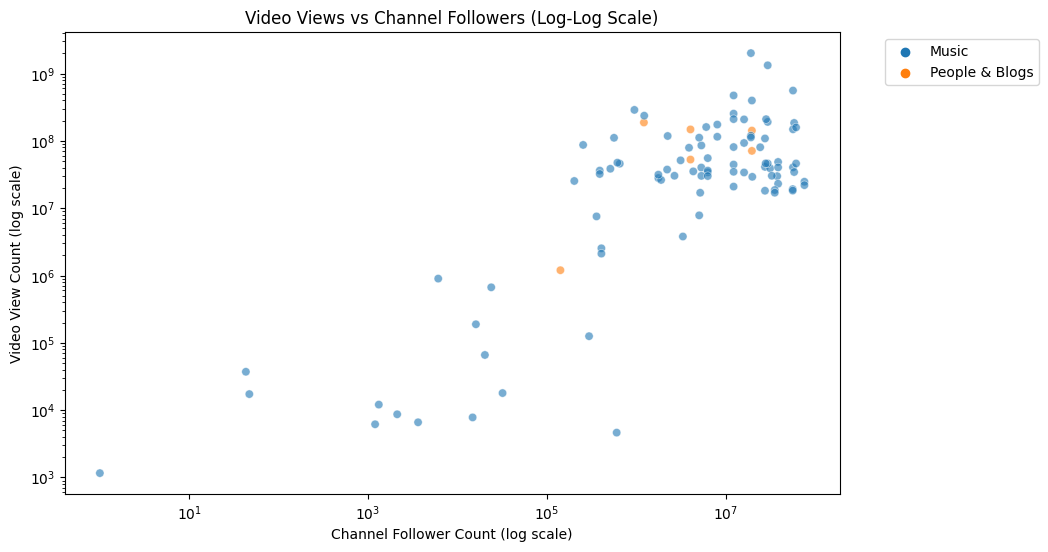

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='channel_follower_count', y='view_count', hue='categories', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title("Video Views vs Channel Followers (Log-Log Scale)")
plt.xlabel("Channel Follower Count (log scale)")
plt.ylabel("Video View Count (log scale)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

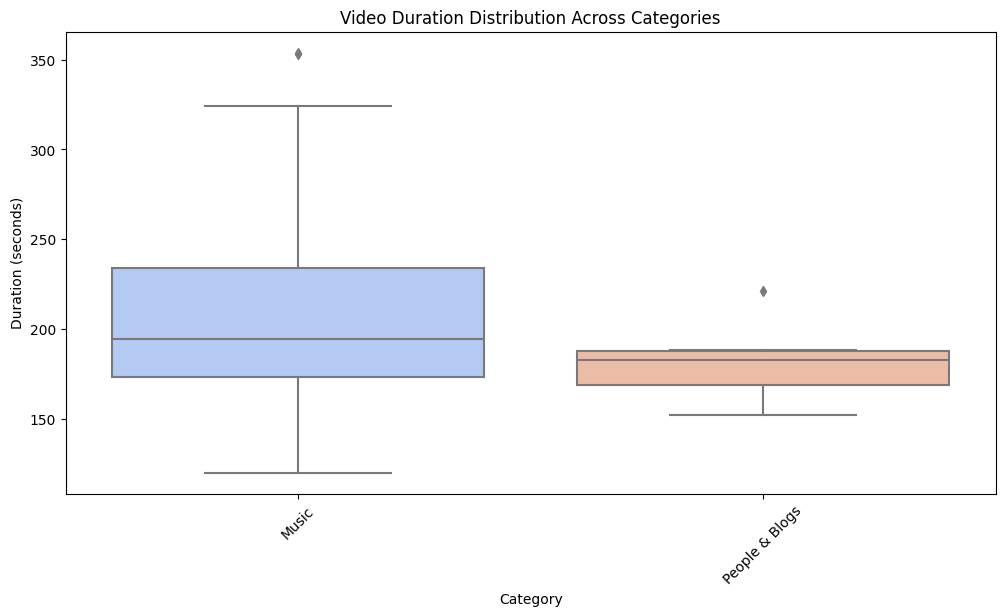

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(x='categories', y='duration', data=df, palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Video Duration Distribution Across Categories")
plt.ylabel("Duration (seconds)")
plt.xlabel("Category")
plt.show()

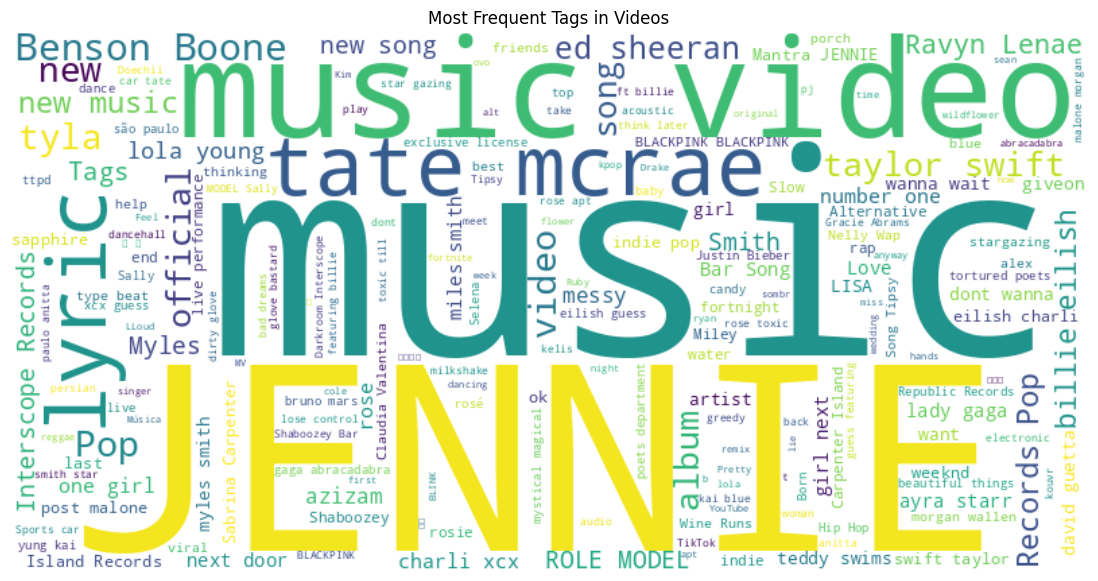

In [19]:
from wordcloud import WordCloud

all_tags = ' '.join(df['tags'].astype(str).tolist())
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_tags)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Tags in Videos")
plt.show()

In [20]:
import plotly.express as px

In [21]:
top_channels = df.groupby('channel')['view_count'].sum().sort_values(ascending=False).head(15).reset_index()
fig = px.bar(top_channels, x='channel', y='view_count', color='view_count', 
             title="Top 15 Channels by Total Views", color_continuous_scale='Blues')
fig.update_layout(xaxis_tickangle=-45)
fig.show()


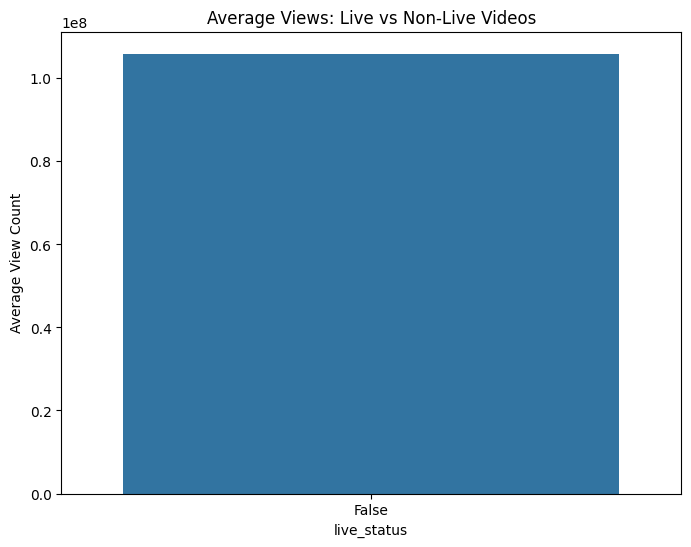

In [22]:
live_views = df.groupby('live_status')['view_count'].mean().reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x='live_status', y='view_count', data=live_views, palette=['#1f77b4','#ff7f0e'])
plt.title("Average Views: Live vs Non-Live Videos")
plt.ylabel("Average View Count")
plt.show()

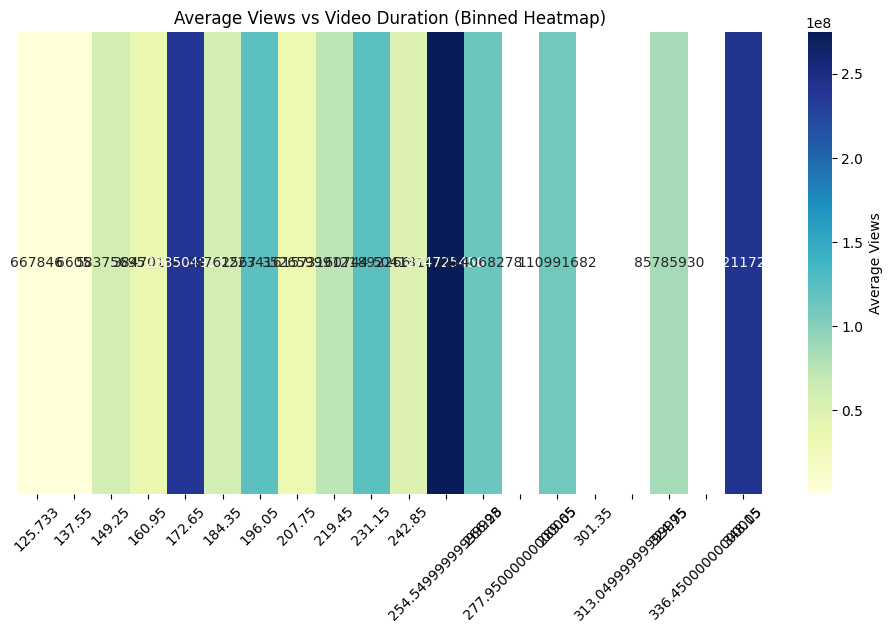

In [23]:
df['duration_bin'] = pd.cut(df['duration'], bins=20)
heatmap_data = df.groupby('duration_bin')['view_count'].mean().reset_index()
heatmap_data['duration_mid'] = heatmap_data['duration_bin'].apply(lambda x: x.mid)

plt.figure(figsize=(12,6))
sns.heatmap([heatmap_data['view_count']], cmap="YlGnBu", annot=True, fmt=".0f", cbar_kws={'label':'Average Views'})
plt.xticks(ticks=np.arange(len(heatmap_data['duration_mid']))+0.5, labels=heatmap_data['duration_mid'], rotation=45)
plt.yticks([])
plt.title("Average Views vs Video Duration (Binned Heatmap)")
plt.show()

## ML Algorithms

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

In [25]:
df['categories'] = df['categories'].fillna('Unknown')
df['tags'] = df['tags'].fillna('No Tags')
df['live_status'] = df['live_status'].fillna('Not Live')

# Convert numeric columns
df['view_count'] = pd.to_numeric(df['view_count'], errors='coerce').fillna(0)
df['channel_follower_count'] = pd.to_numeric(df['channel_follower_count'], errors='coerce').fillna(0)
df['duration'] = pd.to_numeric(df['duration'], errors='coerce').fillna(df['duration'].median())

In [26]:
le_categories = LabelEncoder()
df['categories_encoded'] = le_categories.fit_transform(df['categories'])

le_live = LabelEncoder()
df['live_status_encoded'] = le_live.fit_transform(df['live_status'])


In [27]:
median_views = df['view_count'].median()
df['target'] = np.where(df['view_count'] > median_views, 1, 0)

In [28]:
features = ['duration', 'channel_follower_count', 'categories_encoded', 'live_status_encoded']
X = df[features]
y = df['target']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier()
}


In [31]:
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_results[name] = acc
    print(f"{name} Accuracy: {acc:.2f}%")


Logistic Regression Accuracy: 50.00%
Decision Tree Accuracy: 75.00%
Random Forest Accuracy: 65.00%
Gradient Boosting Accuracy: 60.00%
XGBoost Accuracy: 75.00%
[LightGBM] [Info] Number of positive: 40, number of negative: 40
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001075 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 52
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

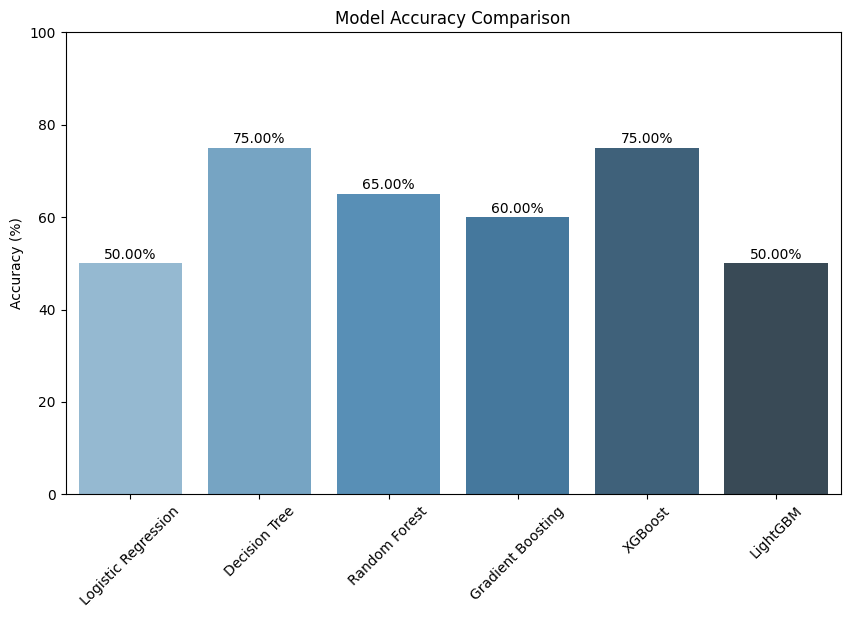

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x=list(accuracy_results.keys()), y=list(accuracy_results.values()), palette="Blues_d")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=45)
for i, v in enumerate(accuracy_results.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.show()

## Thank you..pls upvote!!